## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import sys
import io
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "3"
dataset_type_du = f"{agrupamento}_days_duas_unas"
#validation_method = 'split'

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_1"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_3"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

diretorio_avaliacao_teste_0 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_0"
os.makedirs(diretorio_avaliacao_teste_0, exist_ok=True)

diretorio_avaliacao_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_1"
os.makedirs(diretorio_avaliacao_teste_1, exist_ok=True)

diretorio_avaliacao_teste_2 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_2"
os.makedirs(diretorio_avaliacao_teste_2, exist_ok=True)

diretorio_avaliacao_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_3"
os.makedirs(diretorio_avaliacao_teste_3, exist_ok=True)

diretorio_avaliacao_teste_4 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_4"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)

diretorio_resultados_ensemble = f"Resultados_PSO/pso_du/{agrupamento}_days/Resultados_Ensemble"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type_du]['timesteps'] + config['datasets'][dataset_type_du]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
horizonte = config['datasets'][dataset_type_du]['output_horizon']
#print(f'validation interval',validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dados de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled
print(f,"duas_unas para treinamento e teste:", scaled_datasets[4])
print(f,"duas_unas para validação:", duas_unas_validation_scaled)


<_io.TextIOWrapper name='config_pso.json' mode='r' encoding='cp1252'> duas_unas para treinamento e teste:             kWh fornecido
timestamp                
2023-10-01       0.000000
2023-10-04       0.345662
2023-10-07       0.747771
2023-10-10       0.914409
2023-10-13       0.913913
...                   ...
2024-04-22       0.912180
2024-04-25       0.903549
2024-04-28       0.896600
2024-05-01       0.839799
2024-05-04       0.878018

[73 rows x 1 columns]
<_io.TextIOWrapper name='config_pso.json' mode='r' encoding='cp1252'> duas_unas para validação:             kWh fornecido
timestamp                
2024-05-07       0.817071
2024-05-10       0.831403
2024-05-13       0.835162
2024-05-16       0.768227
2024-05-19       0.960820
2024-05-22       0.946822
2024-05-25       0.954853
2024-05-28       0.956314
2024-05-31       0.950227
2024-06-03       0.947856
2024-06-06       0.949203
2024-06-09       0.963447
2024-06-12       0.964052
2024-06-15       0.972923
2024-06-18       0.97

In [8]:
def save_function_output(func, *args, output_file, output_dir, **kwargs):
    # Redireciona stdout para capturar os prints
    old_stdout = sys.stdout
    new_stdout = io.StringIO()
    sys.stdout = new_stdout
    
    try:
        # Executa a função e captura sua saída
        func(*args, **kwargs)
    finally:
        # Restaura stdout e captura a saída
        sys.stdout = old_stdout
        output = new_stdout.getvalue()
        
        # Cria o diretório se não existir
        os.makedirs(output_dir, exist_ok=True)
        
        # Caminho completo para o arquivo de saída
        save_path = os.path.join(output_dir, output_file)
        
        # Salva a saída em um arquivo
        with open(save_path, 'w') as f:
            f.write(output)
        print(f"Output salvo em: {save_path}")

In [9]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [10]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [11]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [12]:

def create_and_train_model(config, dataset_type, X, y, validation_method, k, tt_rate):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    # Aplicar o método de validação
    if validation_method == 'split':
        # Usar validação por divisão
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=tt_rate, random_state=42)
        
        print(f"X_test shape:",X_val.shape)
        print(f"y_test shape:",y_val.shape)
        
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        callbacks=[early_stopping])
        
        # Ajuste do gráfico para começar em 1
        epochs_range = range(1, len(history.history['loss']) + 1)
        
        plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
        plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    # elif validation_method == 'k-fold':
    # # Usar validação k-fold
    
    #     kf = KFold(n_splits=min(k, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
    #     for train_index, val_index in kf.split(X):
    #         X_train, X_val = X[train_index], X[val_index]
    #         y_train, y_val = y[train_index], y[val_index]
    #         history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
    #                         callbacks=[early_stopping])
        
    #         # Ajuste do gráfico para começar em 1
    #         epochs_range = range(1, len(history.history['loss']) + 1)

    #         plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    #         plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    #         plt.xlabel('Épocas')
    #         plt.ylabel('Perda')
    #         plt.legend()
    #         plt.show()

    return model, X_val, y_val

In [13]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [14]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [15]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [16]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    #pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    #lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [17]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [19]:
# Automatizar os splits de treino/teste
current_filename = None
resultados = []  # Para armazenar os resultados de cada execução
def salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation):
    global current_filename, resultados
    
    # Se o nome do arquivo mudou, salvar os resultados e reiniciar a lista
    if current_filename != diretorio:
        # Atualiza o nome do arquivo atual e reinicia a lista de resultados
        current_filename = diretorio
        resultados = []  # Reinicia a lista de resultados
    
    # Armazenar os resultados
    resultados.append({
        'validation': validation,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'accuracy 2%': acuracia_2,
        'accuracy 5%': acuracia_5,
        'accuracy 10%': acuracia_10,
        'Erro percentual acumulado 30 dias': err_perc_acum_30dias,
        'Erro percentual acumulado 60 dias': err_perc_acum_60dias,
        'Erro percentual acumulado 90 dias': err_perc_acum_90dias,
        'Erro percentual acumulado 1º mês': err_perc_acum_pri_mes,
        'Erro percentual acumulado 2º mês': err_perc_acum_seg_mes,
        'Erro percentual acumulado 3º mês': err_perc_acum_ter_mes
         
        
    })
            
    # Salvar os resultados em um arquivo CSV
    results_df = pd.DataFrame(resultados)
    results_df.to_csv(f'{diretorio}/results.csv', index=False)
    print('Terminada sequencia de testes')

In [20]:
def avaliacao_multistep(janela_real, janela_prevista, diretorio, validation):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    # print(janela_real)
    # print(" ")
    # print(janela_prevista)
    # print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)
    print(" ")
    
    if agrupamento == '1':
        h_1mes = 30
        h_2mes = 60
        
    elif agrupamento == '3':
        h_1mes = 10
        h_2mes = 20

    else:
        h_1mes = 4
        h_2mes = 8

    acumulado_1mes_real = janela_real[:h_1mes].sum()
    # print("acumulado_1mes_real", acumulado_1mes_real)
    acumulado_1e2mes_real = janela_real[:h_2mes].sum()
    # print("acumulado_1e2mes_real", acumulado_1e2mes_real)
    acumulado_1e2e3mes_real = janela_real[:].sum()
    # print("acumulado_1e2e3mes_real", acumulado_1e2e3mes_real)
    acumulado_2mes_real = janela_real[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_real", acumulado_2mes_real)
    acumulado_3mes_real = janela_real[h_2mes:].sum()
    # print("acumulado_3mes_real", acumulado_3mes_real)

    acumulado_1mes_pred = janela_prevista[:h_1mes].sum()
    # print("acumulado_1mes_pred", acumulado_1mes_pred)
    acumulado_1e2mes_pred = janela_prevista[:h_2mes].sum()
    # print("acumulado_1e2mes_pred", acumulado_1e2mes_pred)
    acumulado_1e2e3mes_pred = janela_prevista[:].sum()
    # print("acumulado_1e2e3mes_pred", acumulado_1e2e3mes_pred)
    acumulado_2mes_pred = janela_prevista[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_pred", acumulado_2mes_pred)
    acumulado_3mes_pred = janela_prevista[h_2mes:].sum()
    # print("acumulado_3mes_pred", acumulado_3mes_pred)
    
    err_perc_acum_30dias = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_60dias = round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2)
    err_perc_acum_90dias = round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2)
    err_perc_acum_pri_mes = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_seg_mes = round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2)
    err_perc_acum_ter_mes = round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2)

    print("Erro %. acum 30 dias:", err_perc_acum_30dias,"%")
    print("Erro %. acum 60 dias:", err_perc_acum_60dias,"%")
    print("Erro %. acum 90 dias:", err_perc_acum_90dias,"%")
    print(" ")
    print("Erro %. acum 1º mês:", err_perc_acum_pri_mes,"%")
    print("Erro %. acum 2º mês:", err_perc_acum_seg_mes,"%")
    print("Erro %. acum 3º mês:", err_perc_acum_ter_mes,"%")
    
    salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation)
    
    return

In [21]:
def results(model, validation_dataset_scaled, validation_method, diretorio, validation):
    pred = model.predict(validation_dataset_scaled.iloc[0])
    y_pred_rescaled = scalers[4].inverse_transform(pred)
    y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
    duas_unas_validation_rescaled = scalers[4].inverse_transform(validation_dataset_scaled[1:])

    plt.figure(figsize=(14,6))
    plt.plot(validation_dataset_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
    plt.plot(validation_dataset_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
    plt.yticks(np.arange(0,25000,step=5000))
    plt.title("DATASET TESTE")

        # Nome do arquivo incluindo a variável 'validation_method'
    file_name = f'prediction_plot_with_method_{validation_method}_{validation}.png'

    # Caminho completo para salvar o arquivo
    save_path = os.path.join(diretorio, file_name)

    # Salvar o plot
    plt.savefig(save_path)
    plt.show()
    
    
    #avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio, validation)

    # Nome do arquivo incluindo a variável 'validation_method'
    output_file = f'avaliacao_with_method_{validation_method}_{validation}.txt'
    
    save_function_output(avaliacao_multistep, 
                        duas_unas_validation_rescaled, 
                        y_pred_rescaled,
                        diretorio,
                        validation, 
                        output_file = output_file, 
                        output_dir=diretorio)

In [22]:
from tensorflow.keras.initializers import HeNormal
def transfer_learning_model(config, model, diretorio_pesos, diretorio_resultados, teste, validation_method, k):
    
    # Salvamento dos pesos após primeiro treinamento
    pesos_treinamento = model.get_weights()
    pesos_LSTM1 = model.layers[0].get_weights()
    pesos_LSTM2 = model.layers[2].get_weights()
    pesos_LSTM3 = model.layers[4].get_weights()
    pesos_DENSE = model.layers[6].get_weights()

    # Salvar pesos de cada camada LSTM em arquivos .npz
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM1)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM2)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM3)
    np.savez(os.path.join(diretorio_pesos, f'pesos_DENSE_{teste}_{validation_method}_{k}.npz'), *pesos_DENSE)

    # Para salvar os pesos do modelo completo
    np.savez(os.path.join(diretorio_pesos, f'pesos_modelo_{teste}_{validation_method}_{k}.npz'), *pesos_treinamento)

    # # Carregar pesos do arquivo .npz
    # pesos_carregados_LSTM1 = np.load(os.path.join(diretorio, f'pesos_LSTM1_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM2 = np.load(os.path.join(diretorio, f'pesos_LSTM2_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM3 = np.load(os.path.join(diretorio, f'pesos_LSTM3_{teste}_{validation_method}.npz'))
    
    
    X, y = create_dataset(scaled_datasets[4], config['datasets'][dataset_type_du]['timesteps'], config['datasets'][dataset_type_du]['output_horizon'])
    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_ft = Sequential()

    for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
        model_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model_ft.add(Dropout(0.3))

    model_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type_du]['activation']))

    model_ft.summary()
    
    
    # Caminho dos pesos salvos
    caminho_LSTM1 = os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM2 = os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM3 = os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz')

    carregar_e_aplicar_pesos(model_ft, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3)
        
    congelar_camadas(model_ft)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= k, random_state=42)
    #print(f"X_test", X_test)
    print(f"X_test shape:", X_test.shape)
    #print(f"y_test", y_test)
    print(f"y_test shape:", y_test.shape)

    learning_rate = config['datasets'][dataset_type_du]['learning_rate']

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()
    
    # descongelar_camadas(model_ft)

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

    # learning_rate = 0.0008

    # # Configurar o otimizador
    # optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    # if optimizer == 'adam':
    #     opt = Adam(learning_rate=learning_rate)
    # elif optimizer == 'rmsprop':
    #     opt = RMSprop(learning_rate=learning_rate)
    # else:
    #     opt = SGD(learning_rate=learning_rate)

    # # Configurar a função de perda
    # loss_function = config['datasets'][dataset_type_du]["loss_function"]

    # if loss_function == "wmae":
    #     loss = wmae
    # elif loss_function == "wmse":
    #     loss = wmse

    # model_ft.compile(optimizer=opt, loss=loss)

    # early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

    # history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
    #                 callbacks=[early_stopping])
        
    # # Ajuste do gráfico para começar em 1
    # epochs_range = range(1, len(history.history['loss']) + 1)

    # plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    # plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    # plt.xlabel('Épocas')
    # plt.ylabel('Perda')
    # plt.legend()
    plt.show()

    results(model_ft, duas_unas_validation_scaled, validation_method, diretorio_resultados, k)
    
    return X_test, y_test

## **TESTE 01**
Prata I, II, III e Duas Unas.
Ações a serem testadas:

0. Validar se a técnica de TL que envolve congelamento de camadas é reconhecido e amplamente utilizado;
1. Padronizar cada dataset em separado (Prata I, II, III);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 01 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [1, 2, 3]
dataset_test_1 = concatenate_selected_datasets(scaled_datasets, indices)

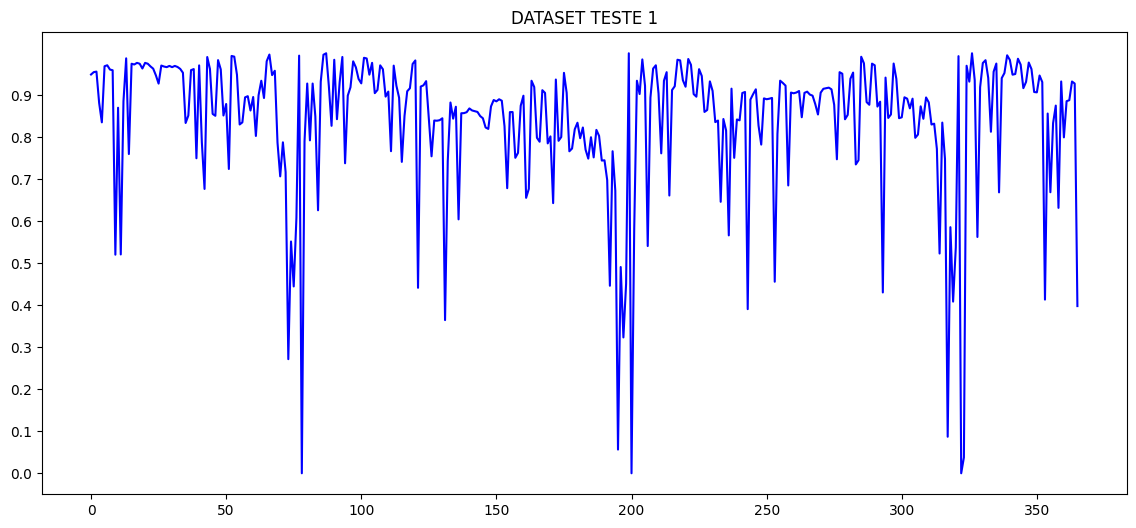

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_1, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_1, y_1 = create_dataset(dataset_test_1, timesteps, output_steps)
X_1 = X_1.reshape(X_1.shape[0], X_1.shape[1], 1)

#model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)

X shape (336, 1)
y shape (336, 30)



Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

X_test shape: (135, 1, 1)
y_test shape: (135, 30)
Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step - loss: 0.7688 - val_loss: 0.4531
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2903 - val_loss: 0.1425
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1735 - val_loss: 0.1267
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1703 - val_loss: 0.1321
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1608 - val_loss: 0.1255
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1582 - val_loss: 0.1305
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1559 - val_loss: 0.1503
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1480 - val_loss: 0.1283
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1480 - val_loss: 0.1188
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1380 - val_loss: 0.1192
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step -

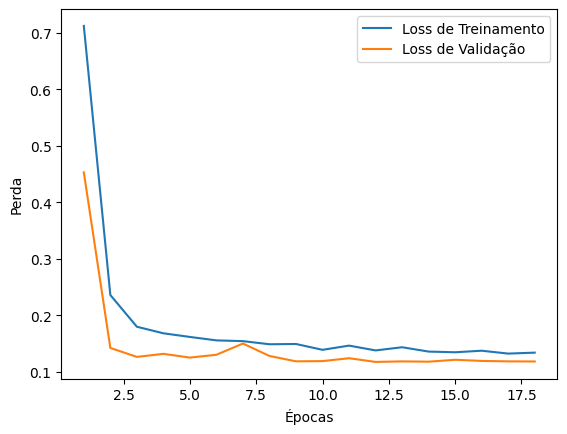

X shape (43, 1)
y shape (43, 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
X_test shape: (35, 1, 1)
y_test shape: (35, 30)
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.8852 - val_loss: 0.8618
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.8687 - val_loss: 0.8423
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.8483 - val_loss: 0.8226
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.8297 - val_loss: 0.8024
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.8091 - val_loss: 0.7803
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.7857 - val_loss: 0.7553
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.7635 - val_loss: 0.7279
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.7357 - val_loss: 0.6974
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.7067 - val_loss: 0.6632
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 

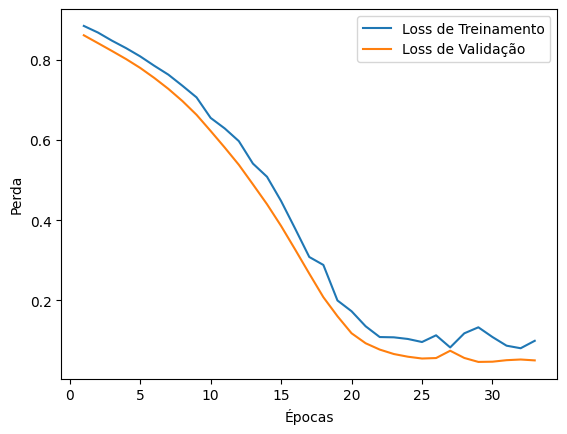

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step


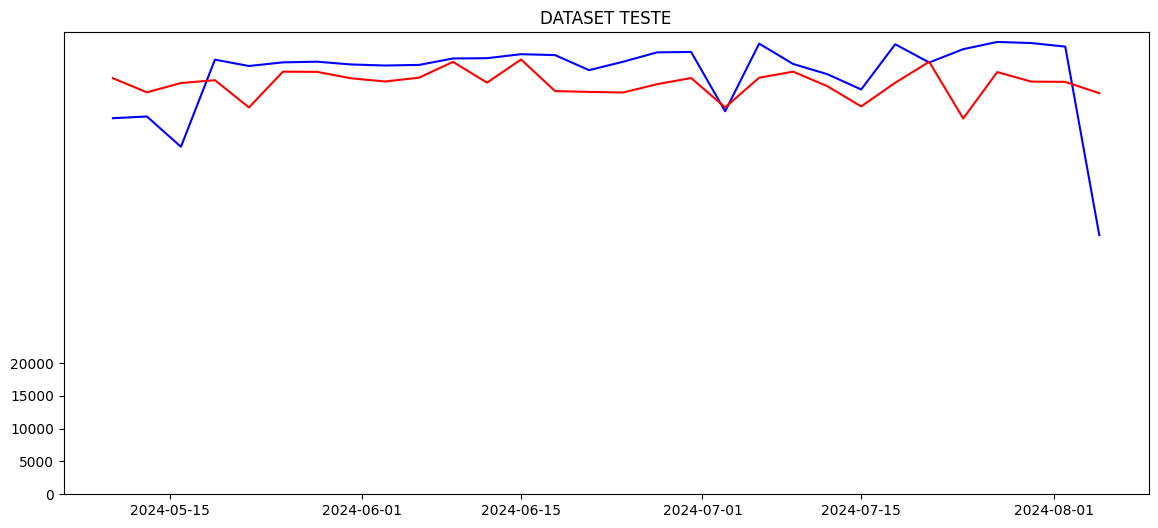

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.8.txt


In [26]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, k=k, tt_rate=0)
#     transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, str(k))
    
# Treinamento com train-test split
# tt_rate = 0
# for k in range(1,10):
#     tt_rate += 0.10
#     print("\nTraining with train-test split")
#     validation_method = 'split'
#     model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, None, tt_rate)
#     transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, tt_rate)
    
print("\nTraining with train-test split")
validation_method = 'split'
model1, X_test_, y_test_ = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, None, 0.4)
X_test_1, y_test_1 = transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, 0.8)



# # Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# # Treinamento com train-test split
# tt_rate = 0
# for k in range(1,10):
#     tt_rate += 0.10
#     print("\nTraining with train-test split")
#     validation_method = 'split'
#     model3 = train_model(X_3, y_3, validation_method, None, tt_rate)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate)

## **TESTE 02**

Prata I, II, III e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [27]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

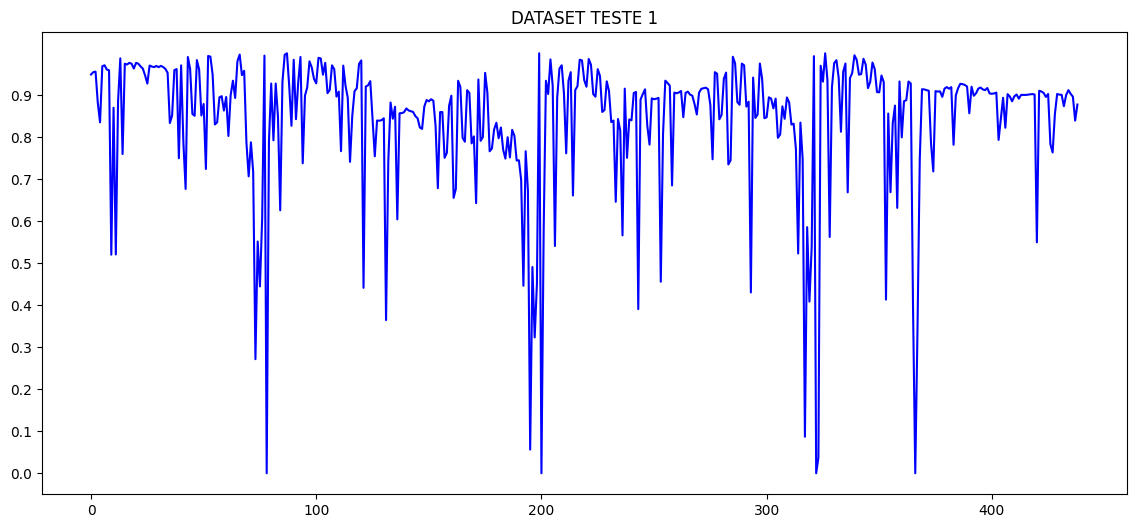

In [28]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [29]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (409, 1)
y shape (409, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

X_test shape: (123, 1, 1)
y_test shape: (123, 30)
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.7204 - val_loss: 0.1455
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1864 - val_loss: 0.1162
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1693 - val_loss: 0.1324
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1683 - val_loss: 0.1339
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1566 - val_loss: 0.1278
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1437 - val_loss: 0.1322
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1481 - val_loss: 0.1549
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1451 - val_loss: 0.1161
Epoch 9/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1390 - val_loss: 0.1158
Epoch 10/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1297 - val_loss: 0.1082
Epoch 11/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step -

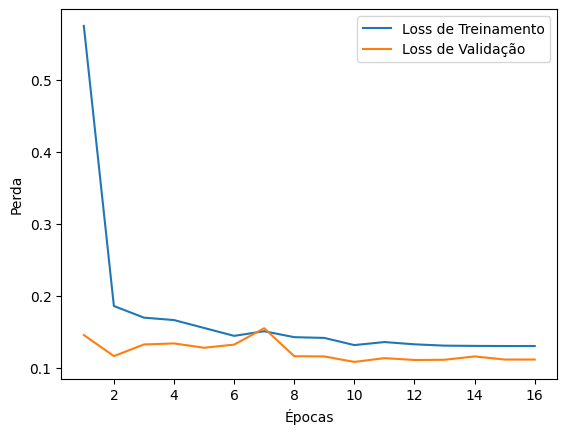

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step


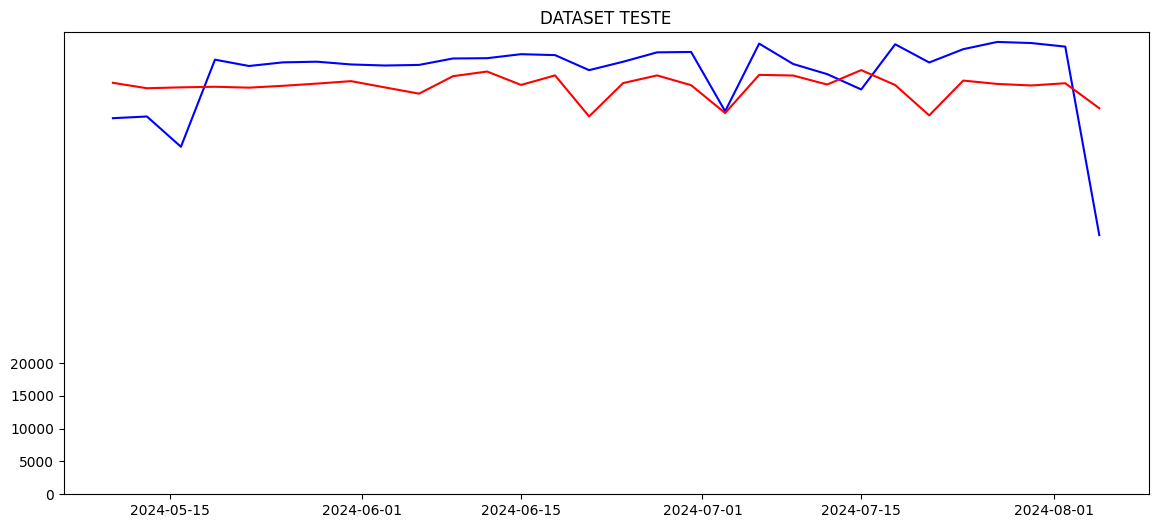

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.3.txt


In [30]:
# for k in range(2,10):
#     model_2 = create_model(config, dataset_type_du, X, y, 'k-fold', k, 0)
#     results(model_2, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_2, k)

model_2, X_test_2, y_test_2 = create_and_train_model(config, dataset_type_du, X, y, 'split', 0, 0.3)
results(model_2, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_2, 0.3)

## **ENSEMBLE**

In [35]:
lstm_tl_pred = model1.predict(X_test_1)
lstm_concat_pred = []
for i in range(0,X_test_1.shape[0]):
    lstm_concat_pred.append(model_2.predict(X_test_1[i]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━

In [36]:
# Cria um novo dataset com as saídas dos modelos [30x1] e [30x1], concatenando uma lista na outra para gerar a nova lista [60x1]
concat_preds_seq = []
for i in range(len(lstm_tl_pred)):    
    pred_lstm_tl_to_concat = lstm_tl_pred[i]
    pred_lstm_concat_to_concat = lstm_concat_pred[i][0]
    # pred_lstm_values = pred_lstm_to_concat.values
    # pred_arima_values = pred_arima_to_concat.values

    conc = np.concatenate(( pred_lstm_tl_to_concat,pred_lstm_concat_to_concat), axis=0)
    # print(pred_arima_to_concat)
    # print(pred_lstm_to_concat)
    # print(conc)
    concat_preds_seq.append(conc)
#print(concat_preds)
concat_preds_seq = np.array(concat_preds_seq)
print(concat_preds_seq.shape)

(35, 60)


In [37]:
# Cria um novo dataset com as saídas dos modelos [30x1] e [30x1], alternando os elementos de cada lista para gerar a nova lista [60x1]
concat_preds_alt = []
for i in range(len(lstm_tl_pred)):    
    pred_lstm_tl_to_concat = lstm_tl_pred[i]
    pred_lstm_concat_to_concat = lstm_concat_pred[i][0]
    lista_combinada = [item for pair in zip(pred_lstm_tl_to_concat, pred_lstm_concat_to_concat) for item in pair]
    concat_preds_alt.append(lista_combinada)
#print(concat_preds)
concat_preds_alt = np.array(concat_preds_alt)
print(concat_preds_alt.shape)

(35, 60)


In [38]:
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(concat_preds_alt, y_test_1, test_size=0.3, random_state=42)

c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.7719 - val_loss: 0.5342
Epoch 2/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5204 - val_loss: 0.4595
Epoch 3/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4418 - val_loss: 0.3820
Epoch 4/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3741 - val_loss: 0.3544
Epoch 5/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3478 - val_loss: 0.3272
Epoch 6/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3102 - val_loss: 0.2677
Epoch 7/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2711 - val_loss: 0.2457
Epoch 8/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2428 - val_loss: 0.2212
Epoch 9/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2207 - val_loss: 0.1755
Epoch 10/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1913 - val_loss: 0.1653
Epoch 11/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1719 - val_loss: 0.1648
Epoch 12/10000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/ste

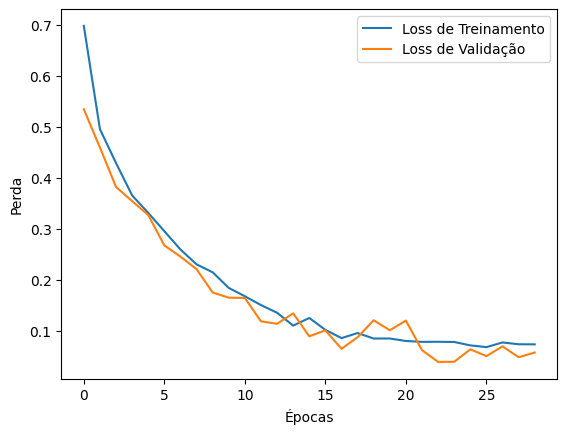

In [39]:
from keras.models import Sequential
from keras.layers import Dense

# Definindo o tamanho da entrada e da saída
input_shape = 60  # Tamanho da sequência de entrada
output_shape = 30  # Tamanho da janela de previsão de saída

# Criando o modelo
model_mlp = Sequential()
model_mlp.add(Dense(256, input_dim=input_shape, activation='relu'))
#model_mlp.add(Dense(256, activation='relu'))                         # Camada oculta 1
model_mlp.add(Dense(128, activation='relu'))                         # Camada oculta 1
model_mlp.add(Dense(64, activation='relu'))                          # Camada oculta 2
model_mlp.add(Dense(32, activation='relu'))                          # Camada oculta 3
model_mlp.add(Dense(output_shape, activation='linear'))              # Camada de saída (para regressão)

# Definindo o otimizador com a taxa de aprendizado
optimizer = RMSprop(learning_rate=0.001)

# Compilando o modelo
model_mlp.compile(loss=wmae, optimizer=optimizer)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=6, restore_best_weights=True)

# Treinando o modelo
history = model_mlp.fit(X_train_mlp, y_train_mlp, epochs=10000, batch_size=4, validation_data=(X_test_mlp, y_test_mlp), callbacks=[early_stopping])

# Plotar as perdas de treinamento e validação
plt.plot(history.history['loss'], label='Loss de Treinamento')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [40]:
entrada_lstm = np.array([[[duas_unas_validation_scaled.iloc[0][0]]]])

C:\Users\Renan Torres\AppData\Local\Temp\ipykernel_17360\4096010643.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  entrada_lstm = np.array([[[duas_unas_validation_scaled.iloc[0][0]]]])


In [41]:
pred_tl = model1.predict(entrada_lstm)
pred_concat = model_2.predict(entrada_lstm[0])
lista_combinada = [item for pair in zip(pred_tl, pred_concat) for item in pair]
concat_preds_alt = np.array(lista_combinada)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


MAE(Erro absoluto médio) Score of LSTM model =  5109.138
 
MSE(Erro quadrático médio) Score of LSTM model =  38258209.314
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  6185.322
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.08
 
2% Accuracy Score of LSTM model =  6.67
5% Accuracy Score of LSTM model =  13.33
10% Accuracy Score of LSTM model =  73.33
 
Erro %. acum 30 dias: 1.94 %
Erro %. acum 60 dias: 4.45 %
Erro %. acum 90 dias: 4.04 %
 
Erro %. acum 1º mês: 1.94 %
Erro %. acum 2º mês: 6.96 %
Erro %. acum 3º mês: 3.23 %
Terminada sequencia de testes


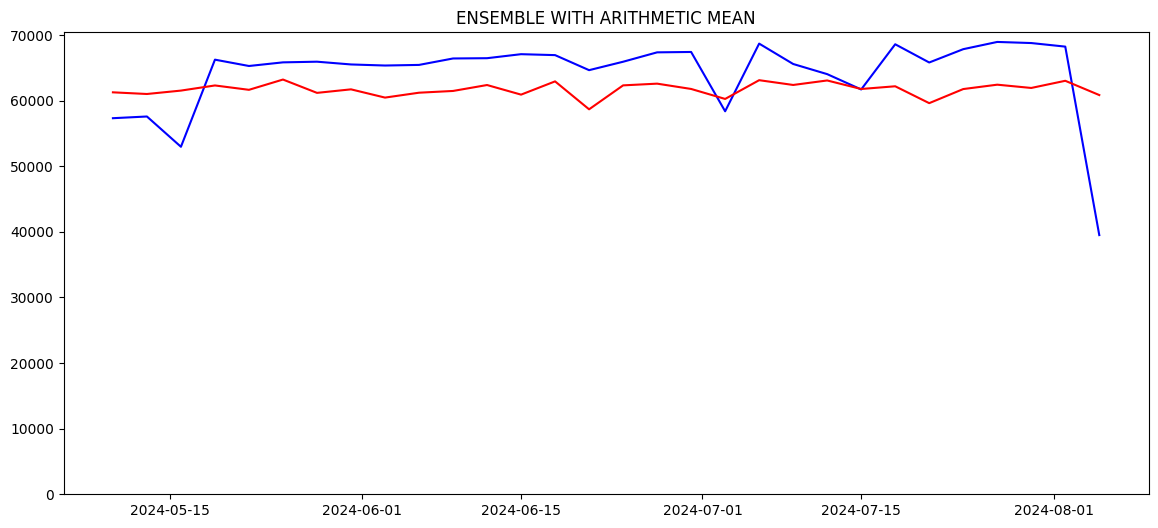

In [44]:
pred_med = []
for i in range (len(pred_tl[0])):
    med = (pred_tl[0][i] + pred_concat[0][i])/2
    #print(med)
    pred_med.append(med)

pred_med = np.array(pred_med)
pred_med_reshaped = pred_med.reshape(1, -1)

y_pred_rescaled = scalers[4].inverse_transform(pred_med_reshaped)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("ENSEMBLE WITH ARITHMETIC MEAN")

avaliacao_multistep(y_pred_rescaled, duas_unas_validation_rescaled, diretorio_resultados_ensemble, 'MLP_seq')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


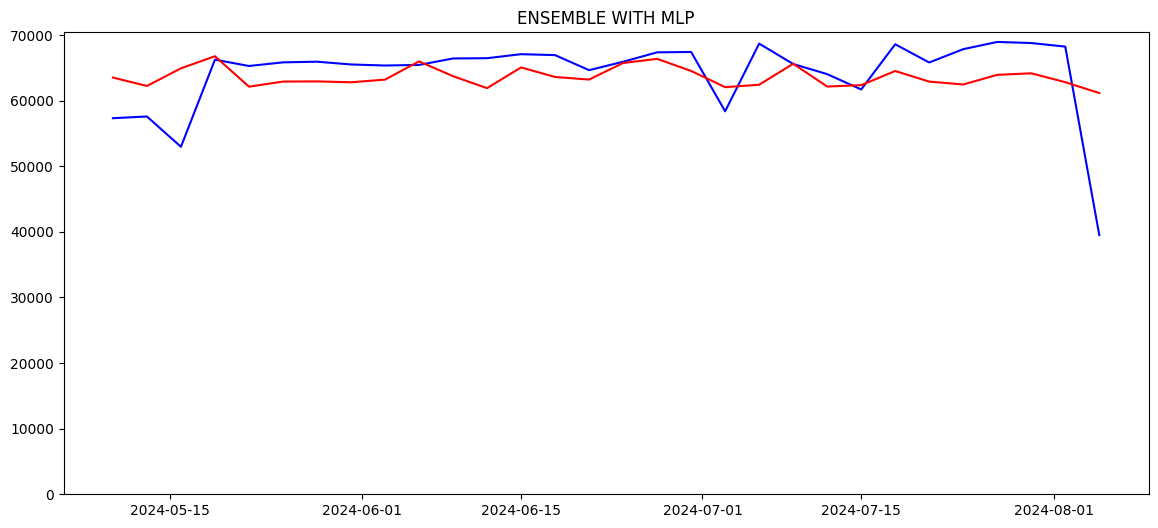

MAE(Erro absoluto médio) Score of LSTM model =  3917.614
 
MSE(Erro quadrático médio) Score of LSTM model =  31773637.944
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  5636.811
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.06
 
2% Accuracy Score of LSTM model =  20.0
5% Accuracy Score of LSTM model =  53.33
10% Accuracy Score of LSTM model =  90.0
 
Erro %. acum 30 dias: 1.56 %
Erro %. acum 60 dias: 0.85 %
Erro %. acum 90 dias: 0.93 %
 
Erro %. acum 1º mês: 1.56 %
Erro %. acum 2º mês: 3.24 %
Erro %. acum 3º mês: 1.1 %
Terminada sequencia de testes


In [43]:
# X_val_concat = np.concatenate((pred_tl,pred_concat), axis=0)
# X_val_concat_array = np.array(X_val_concat)
X_val_concat = np.array(concat_preds_alt).reshape(1, -1)  # shape será (1, 60)

pred = model_mlp.predict(X_val_concat)
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("ENSEMBLE WITH MLP")

# Nome do arquivo incluindo a variável 'validation_method'
file_name = f'prediction_plot_with_MLP_input_seq.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_resultados_ensemble, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

avaliacao_multistep(y_pred_rescaled, duas_unas_validation_rescaled, diretorio_resultados_ensemble, 'MLP_seq')